# Viewing Results from Simulation Runs

This notebook provides a few example functions to view and interact with the images generated from the [CT_dataset_pipeline.py](../CT_dataset_pipeline.py).

To begin, locate the `metadata.csv` output by the simulation run specified by the `base_dir` variable in [CT_dataset_pipeline.py](../CT_dataset_pipeline.py), using Pandas this metadata file enables quickly filtering and working with the images to select the examples of interest.

In [1]:
!ls /gpfs_projects/brandon.nelson/pedsilicoICH/pedsilicoICH_09-23-2024/

ls: cannot access '/gpfs_projects/brandon.nelson/pedsilicoICH/pedsilicoICH_09-23-2024/': No such file or directory


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
study_name = 'pedsilicoICH_09-23-2024_13-09'
base_dir = Path('/gpfs_projects/brandon.nelson/pedsilicoICH') / study_name
metadata = pd.concat([pd.read_csv(o) for o in base_dir.rglob('*.csv')], ignore_index=True).sort_values(by=['name', 'image file']).reset_index(drop=True)
metadata.loc[~metadata.intensity.isna(), 'lesion type'] = metadata[~metadata.intensity.isna()]['lesion type'].apply(lambda x: x.split("['")[-1].split("']")[0])
metadata.loc[~metadata.intensity.isna(), 'intensity'] = metadata[~metadata.intensity.isna()]['intensity'].apply(lambda x: x.split('(')[-1].split(')')[0]).astype(int)
metadata['image file']=metadata['image file'].apply(lambda x: base_dir / str(x.split(study_name+'/')[-1]))
metadata.loc[~metadata['mask file'].isna(), 'mask file']=metadata.loc[~metadata['mask file'].isna(), 'mask file'].apply(lambda x: base_dir / str(x.split(study_name+'/')[-1]))
metadata

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file
0,case_000,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN
1,case_000,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN
2,case_000,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN
3,case_000,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN
4,case_000,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16095,case_099,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,200,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN
16096,case_099,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,200,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN
16097,case_099,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,200,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN
16098,case_099,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,200,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN


In [3]:
for n in metadata['name'].unique():
    metadata.loc[metadata['name'] == n, 'slice'] = list(range(len( metadata[metadata['name'] == n])))
metadata['slice'] = metadata['slice'].astype(int)

In [4]:
metadata[~metadata.name.duplicated()]

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
0,case_000,11.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
161,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
322,case_002,11.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
483,case_003,10.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
630,case_004,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15225,case_095,38.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
15435,case_096,38.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
15645,case_097,11.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,100,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
15806,case_098,9.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0


In [5]:
metadata[metadata.name=='case_004']['lesion volume [mL]'].sum()

np.float64(1.6584526747465134)

In [6]:
metadata[metadata.name=='case_001']['lesion volume [mL]'].sum()

np.float64(2.95066274702549)

In [7]:
metadata[(metadata['lesion volume [mL]']>0)]

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
272,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.075088,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,111
273,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.528293,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,112
274,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.570668,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,113
275,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.536907,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,114
276,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.481145,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15811,case_098,9.00,93,225.0,243.0,6.0,epidural,True,0.728061,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,5
15812,case_098,9.00,93,225.0,243.0,6.0,epidural,True,0.752392,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,6
15813,case_098,9.00,93,225.0,243.0,6.0,epidural,True,0.763801,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,7
15814,case_098,9.00,93,225.0,243.0,6.0,epidural,True,0.696862,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,8


## Interactive Viewing using IPywidgets

In [8]:
from pedsilicoICH.image_acquisition import read_dicom
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

from utils import display_settings, browse_studies, study_viewer

In [9]:
study_viewer(metadata)

interactive(children=(Dropdown(description='name', options=('case_000', 'case_001', 'case_002', 'case_003', 'c…

## Viewing the ground truth ICH segmentation masks

The `mask file` column contains the file location containing the ICH mask associated with each image. 

In [10]:
from utils import load_vol

You can filter by `name` to get the intensity and radius of the lesion (it's a sphere in this instance)

Here's an example of how to get the lesion center coordinates from the mask (note the current `center x`, `center y`, `center z` values in `metadata.csv` refer to the coordinates in object space which don't necesarily equal the coordinates in the reconstructed image space due to the effects of the selected reconstructed field of view and magnification.

In [11]:
from utils import get_lesion_coords

With these coordinates we can center the displayed image at the z slice centered about the lesion.

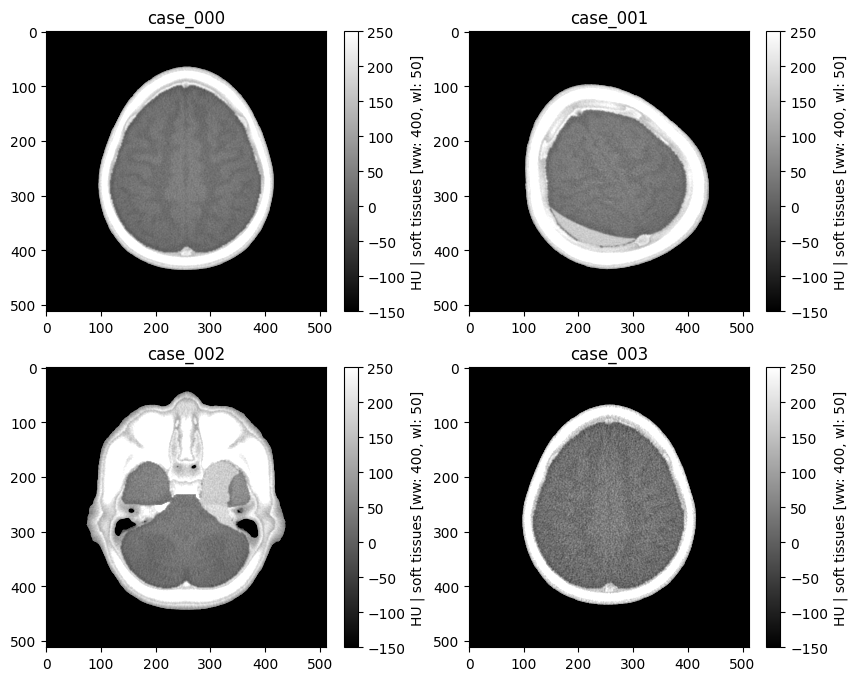

In [12]:
f, axs = plt.subplots(2,2, figsize=(10,8))
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    if metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        z = 100
    else:
        z, x, y = get_lesion_coords(load_vol(metadata[metadata['name'] == case]['mask file']))
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax, display='soft tissues')

### Highlighting the lesion location with a bounding box

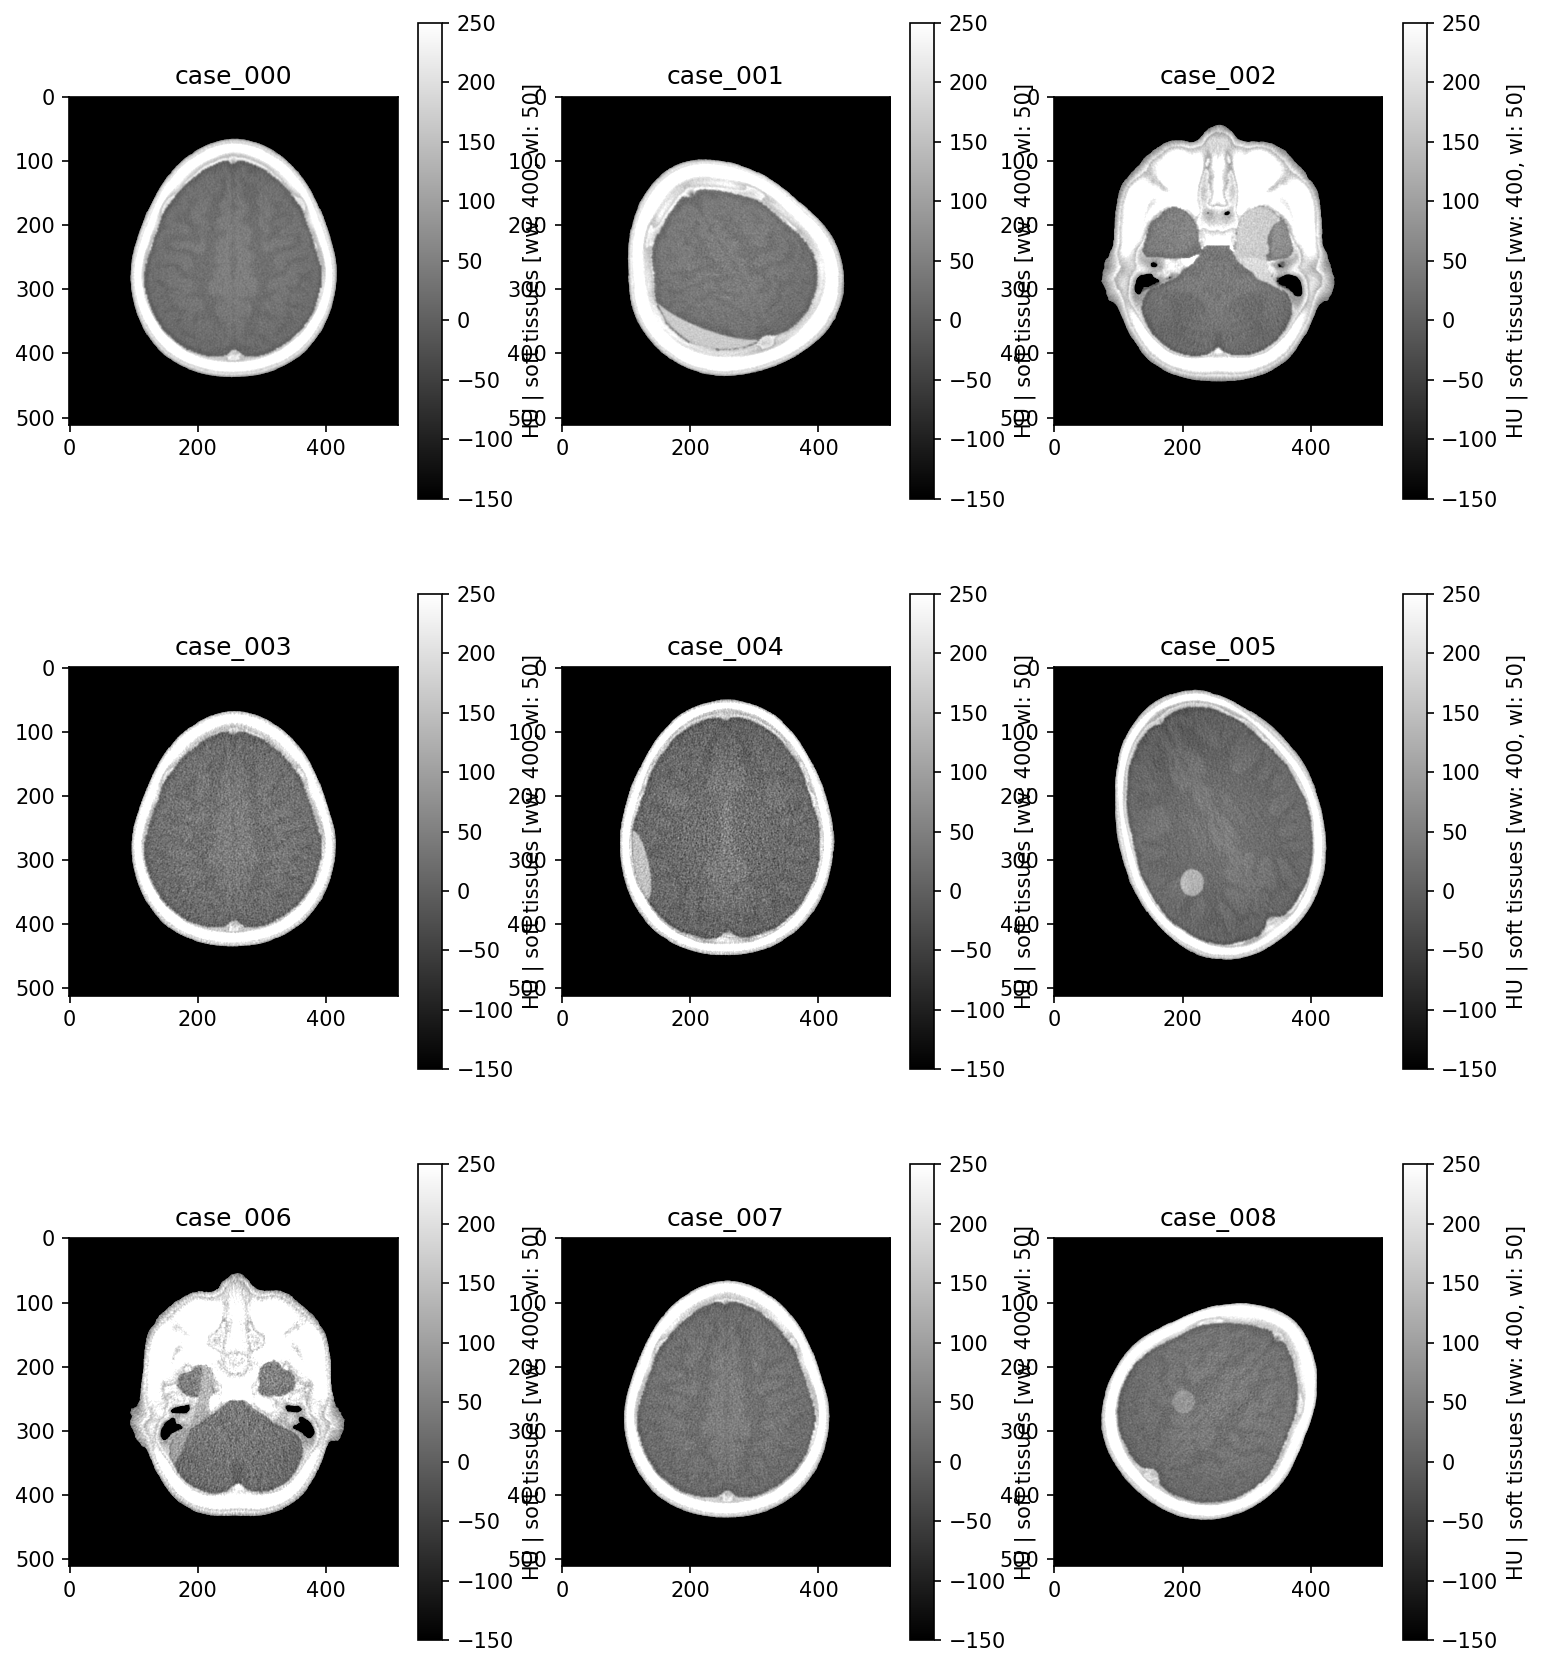

In [13]:
from matplotlib.patches import Rectangle 
nrows = 3
ncols = 3
f, axs = plt.subplots(nrows,ncols, figsize=(nrows*4,ncols*4+2), dpi=150)
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    if metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        z = 100
    else:
        z, x, y = get_lesion_coords(load_vol(metadata[metadata['name'] == case]['mask file']))
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax)
    # width = 3*metadata[metadata['name'] == case]['radius'].unique()[0]
    # ax.add_patch(Rectangle((x-width/2, y-width/2), width=width, height=width, fc ='none', ec ='g', lw = 1))

### Highlighting the lesion location with a segmentation mask overlay

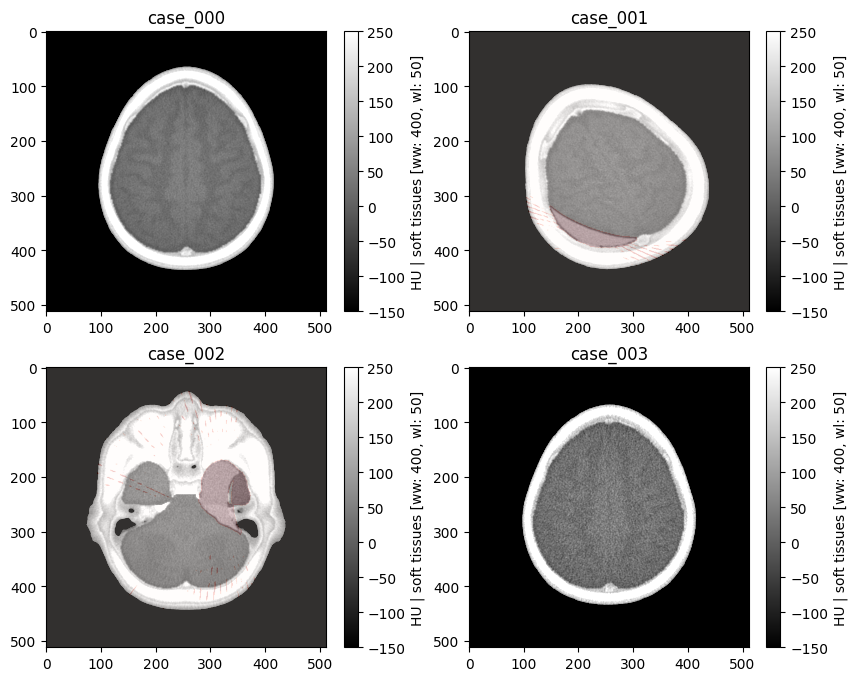

In [14]:
f, axs = plt.subplots(2,2, figsize=(10,8))
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    if not metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        mask = load_vol(metadata[metadata['name'] == case]['mask file'])
        z, x, y = get_lesion_coords(mask)
    else:
         z = 100
    img = load_vol(metadata[metadata['name'] == case]['image file'])
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax)
    if not metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        ax.imshow(mask[z] & (img[z]>-300), cmap='Reds', alpha=0.2)

## Reformated Views

In [15]:
from utils import scrollview
vol = load_vol(metadata[metadata['name']=='case_000']['image file'])

vol.shape

(161, 512, 512)

In [16]:
scrollview(vol)

interactive(children=(IntSlider(value=80, description='idx', max=160), Output()), _dom_classes=('widget-intera…

In [17]:
scrollview(vol.transpose(1,0,2)[:,::-1])

interactive(children=(IntSlider(value=256, description='idx', max=511), Output()), _dom_classes=('widget-inter…

In [18]:
scrollview(vol.transpose(2,0,1)[:, ::-1])

interactive(children=(IntSlider(value=256, description='idx', max=511), Output()), _dom_classes=('widget-inter…

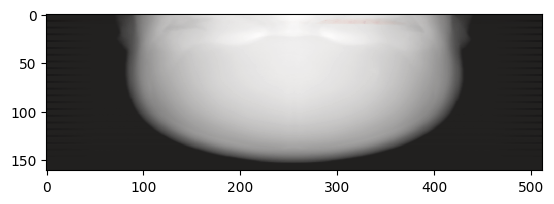

In [19]:
plt.imshow(vol.sum(axis=1), cmap='gray')
plt.imshow(mask.sum(axis=1), cmap='Reds', alpha=0.1)

In [20]:
metadata['lesion type'].unique()

array([nan, 'subdural', 'epidural', 'sphere'], dtype=object)

In [21]:
metadata[(metadata['lesion type'] == 'epidural')].sort_values(by='lesion volume [mL]')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
12144,case_076,10.5,57,415.0,223.0,72.0,epidural,False,0.001397,200,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,76
5858,case_036,10.5,65,219.0,364.0,30.0,epidural,False,0.009197,100,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,27
8979,case_056,12.0,170,256.0,300.0,127.0,epidural,True,0.075903,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,131
11340,case_071,38.0,197,225.0,235.0,94.0,epidural,True,0.117347,200,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,91
5772,case_035,12.0,38,292.0,394.0,99.0,epidural,False,0.177184,200,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11100,case_070,6.5,89,223.0,282.0,5.0,epidural,True,1.271488,250,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,5
11102,case_070,6.5,89,223.0,282.0,5.0,epidural,True,1.293141,250,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,7
11101,case_070,6.5,89,223.0,282.0,5.0,epidural,True,1.304667,250,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,6
10185,case_064,6.5,126,233.0,172.0,13.0,epidural,False,1.335284,150,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,14


In [22]:
metadata[(metadata['lesion type'] == 'subdural')].sort_values(by='lesion volume [mL]')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
9083,case_057,11.50,176,252.0,83.0,70.0,subdural,True,0.043074,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,74
9077,case_057,11.50,176,252.0,83.0,70.0,subdural,True,0.074855,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,68
272,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.075088,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,111
10423,case_065,11.50,64,167.0,147.0,95.0,subdural,False,0.101747,250,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,98
10764,case_067,10.50,179,262.0,328.0,127.0,subdural,False,0.105356,100,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11632,case_073,10.50,196,220.0,234.0,11.0,subdural,False,1.453445,100,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,12
1890,case_011,38.00,130,269.0,155.0,112.0,subdural,True,1.572305,250,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,112
1889,case_011,38.00,130,269.0,155.0,112.0,subdural,True,1.577544,250,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,111
1891,case_011,38.00,130,269.0,155.0,112.0,subdural,True,1.647044,250,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,113


In [23]:
metadata[(metadata['lesion type'] == 'sphere')].sort_values(by='lesion volume [mL]')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
7223,case_045,15.75,27,148.0,213.0,65.0,sphere,False,0.001281,150,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,55
3217,case_020,12.00,135,312.0,307.0,11.0,sphere,True,0.001630,200,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,4
11823,case_074,6.50,171,372.0,292.0,62.0,sphere,True,0.002678,150,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,56
8792,case_055,10.50,143,303.0,155.0,92.0,sphere,True,0.003260,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,91
5286,case_032,9.00,111,293.0,320.0,71.0,sphere,False,0.003376,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7231,case_045,15.75,27,148.0,213.0,65.0,sphere,False,0.198139,150,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,63
7235,case_045,15.75,27,148.0,213.0,65.0,sphere,False,0.200234,150,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,67
7232,case_045,15.75,27,148.0,213.0,65.0,sphere,False,0.202912,150,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,64
7234,case_045,15.75,27,148.0,213.0,65.0,sphere,False,0.204542,150,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,66


In [24]:
np.isnan(metadata['lesion type'].unique()[0])

np.True_

In [25]:
metadata[(~metadata['lesion type'].isna())]['name'].unique()

array(['case_001', 'case_002', 'case_004', 'case_005', 'case_006',
       'case_008', 'case_009', 'case_010', 'case_011', 'case_012',
       'case_014', 'case_017', 'case_018', 'case_019', 'case_020',
       'case_021', 'case_023', 'case_027', 'case_028', 'case_029',
       'case_031', 'case_032', 'case_034', 'case_035', 'case_036',
       'case_037', 'case_038', 'case_040', 'case_041', 'case_042',
       'case_043', 'case_045', 'case_046', 'case_047', 'case_048',
       'case_049', 'case_051', 'case_052', 'case_054', 'case_055',
       'case_056', 'case_057', 'case_058', 'case_059', 'case_061',
       'case_062', 'case_063', 'case_064', 'case_065', 'case_067',
       'case_068', 'case_070', 'case_071', 'case_073', 'case_074',
       'case_075', 'case_076', 'case_077', 'case_080', 'case_081',
       'case_082', 'case_084', 'case_085', 'case_086', 'case_087',
       'case_089', 'case_090', 'case_091', 'case_096', 'case_097',
       'case_098'], dtype=object)

In [26]:
metadata[(metadata['lesion volume [mL]']>0)]

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
272,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.075088,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,111
273,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.528293,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,112
274,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.570668,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,113
275,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.536907,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,114
276,case_001,15.75,187,379.0,243.0,113.0,subdural,True,0.481145,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15811,case_098,9.00,93,225.0,243.0,6.0,epidural,True,0.728061,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,5
15812,case_098,9.00,93,225.0,243.0,6.0,epidural,True,0.752392,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,6
15813,case_098,9.00,93,225.0,243.0,6.0,epidural,True,0.763801,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,7
15814,case_098,9.00,93,225.0,243.0,6.0,epidural,True,0.696862,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,8


In [27]:
[metadata[(metadata['lesion type'] == lesion)]['name'].unique() for lesion in ['sphere', 'epidural', 'subdural']]

[array(['case_005', 'case_008', 'case_018', 'case_019', 'case_020',
        'case_028', 'case_029', 'case_031', 'case_032', 'case_034',
        'case_045', 'case_047', 'case_048', 'case_049', 'case_054',
        'case_055', 'case_062', 'case_068', 'case_074', 'case_077',
        'case_085', 'case_086', 'case_087'], dtype=object),
 array(['case_004', 'case_014', 'case_017', 'case_035', 'case_036',
        'case_037', 'case_041', 'case_042', 'case_043', 'case_052',
        'case_056', 'case_058', 'case_063', 'case_064', 'case_070',
        'case_071', 'case_076', 'case_080', 'case_081', 'case_082',
        'case_084', 'case_089', 'case_091', 'case_097', 'case_098'],
       dtype=object),
 array(['case_001', 'case_002', 'case_006', 'case_009', 'case_010',
        'case_011', 'case_012', 'case_021', 'case_023', 'case_027',
        'case_038', 'case_040', 'case_046', 'case_051', 'case_057',
        'case_059', 'case_061', 'case_065', 'case_067', 'case_073',
        'case_075', 'case_090', '

In [28]:
metadata[(metadata['name']=='case_001')]

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
161,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
162,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,1
163,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,2
164,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,3
165,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,156
318,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,157
319,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,158
320,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,159


## Fig. 1 Plot Showing Dataset Labels 3 lesion types with masks

In [29]:
z

100

In [30]:
metadata[(metadata['name'] == case) ]

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
483,case_003,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
484,case_003,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,1
485,case_003,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,2
486,case_003,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,3
487,case_003,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,case_003,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,142
626,case_003,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,143
627,case_003,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,144
628,case_003,10.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,145


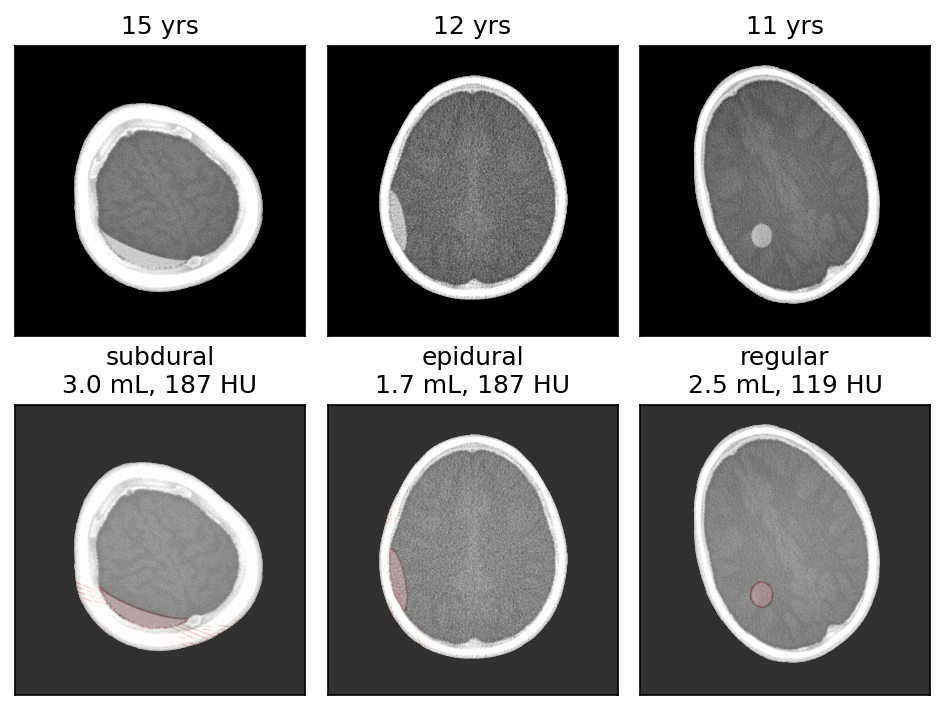

In [34]:
from utils import ctshow

cases = [metadata[metadata['lesion type'] == lesion]['name'].iloc[0] for lesion in metadata['lesion type'].unique() if len(metadata[metadata['lesion type'] == lesion]['name'])>0]
f, axs = plt.subplots(2, len(cases), dpi=150, tight_layout=True)
if axs.ndim < 2:
    axs = axs[:, None]

for idx, case in enumerate(cases):
    z = metadata[(metadata['name'] == case) & (metadata['lesion volume [mL]']>0)]['center z'].iloc[0].astype(int)+1
    mask = read_dicom(metadata[(metadata['name'] == case) & (metadata['slice']==z)]['mask file'].item())
    img = read_dicom(metadata[(metadata['name'] == case) & (metadata['slice']==z)]['image file'].item())

    age =  metadata[metadata['name'] == case].iloc[z]['age'].astype(int)
    
    lesion_type = metadata[metadata['name'] == case].iloc[z]['lesion type']
    lesion_type = 'regular' if lesion_type == 'sphere' else lesion_type
    vol =  metadata[metadata['name'] == case]['lesion volume [mL]'].sum()
    intensity = metadata[metadata['name'] == case].iloc[z]['intensity']
    
    ctshow(img, fig=f, ax=axs[0, idx], window='soft tissues')
    axs[0, idx].set_title(f'{age} yrs')
    ctshow(img, fig=f, ax=axs[1, idx], window='soft tissues')
    axs[1, idx].imshow(mask & (img > 0), cmap='Reds', alpha=0.2)
    axs[1, idx].set_title(f'{lesion_type}\n{vol:2.1f} mL, {intensity} HU')

## Fig. 2 Plot Comparisons of Different kVp, mA, Recon Kernel

In [32]:
metadata[(~metadata['name'].duplicated())].sort_values(by='mA')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
483,case_003,10.50,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
630,case_004,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
952,case_006,10.50,116,229.0,247.0,2.0,subdural,False,0.252854,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
2464,case_015,9.00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
3689,case_023,38.00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10780,case_068,6.50,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
10934,case_069,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
15435,case_096,38.00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
15225,case_095,38.00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0


In [33]:
metadata[(~metadata['name'].duplicated())].sort_values(by='kVp')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
0,case_000,11.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
161,case_001,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
322,case_002,11.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
483,case_003,10.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
630,case_004,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15225,case_095,38.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
15435,case_096,38.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
15645,case_097,11.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,100,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
15806,case_098,9.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,50,120,1000,250,standard,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0


## Fig 3. Pilot Study ROC curves with real and synthetic data